Healthcare Stroke Prediction Analysis
-

According to World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.

The dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases and smoking status. Each row in the data provides relevant information about the patient.

(Classification Task)


Importing Libraries and Dataset
-

In [427]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.metrics import (
    accuracy_score, classification_report, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import OneHotEncoder

In [428]:
stroke_prediction = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")

stroke_prediction.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Understanding the Dataset
-

Checking the shape and Summary Description of the Dataset

In [429]:
print("The Shape of the Dataset: ",stroke_prediction.shape)
print("Description of the Dataset: \n",stroke_prediction.describe())


The Shape of the Dataset:  (5110, 12)
Description of the Dataset: 
                  id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    

Understanding Target Column (stroke)
-

In [430]:
stroke_prediction['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Checking for Missing Values
-

In [431]:
stroke_prediction.isnull().sum().sort_values(ascending=False)

bmi                  201
id                     0
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Handling Missing Values on bmi
-

Handling missing values by using the computed median value of bmi maintaining consistency in the dataset

In [432]:
stroke_prediction['bmi'] = stroke_prediction['bmi'].fillna(stroke_prediction['bmi'].median())

stroke_prediction.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Data Visualization
-

Distribution Across Gender and Age with Hypertension

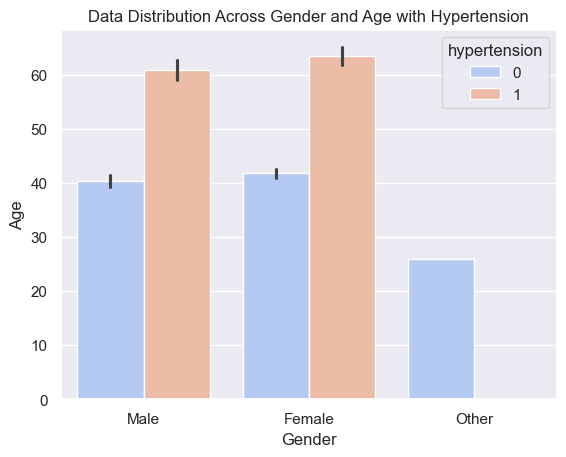

In [433]:
sns.barplot(data=stroke_prediction, x='gender', y='age', palette='coolwarm', hue='hypertension')

plt.title('Data Distribution Across Gender and Age with Hypertension')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

Distribution Across Gender and Age with Heart Disease

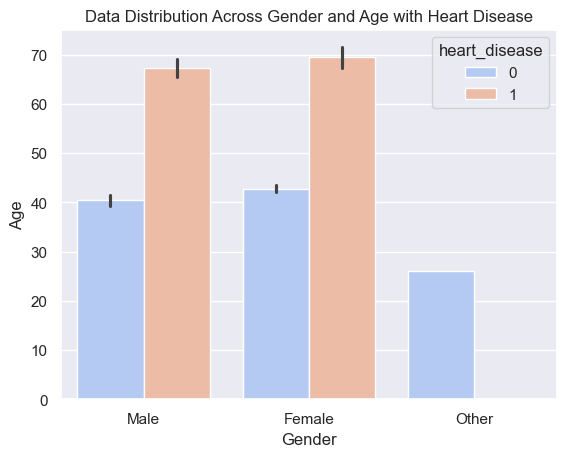

In [434]:
sns.barplot(data=stroke_prediction, x='gender', y='age', palette='coolwarm', hue='heart_disease')

plt.title('Data Distribution Across Gender and Age with Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

Distribution Across Work type

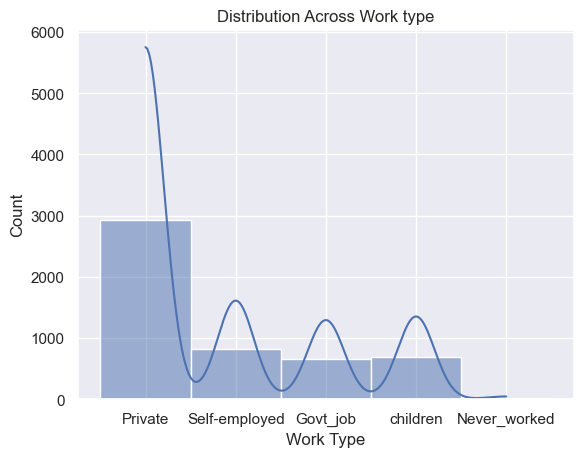

In [435]:
sns.histplot(data=stroke_prediction, x='work_type', kde=True)

plt.title('Distribution Across Work type')
plt.xlabel('Work Type')
plt.show()

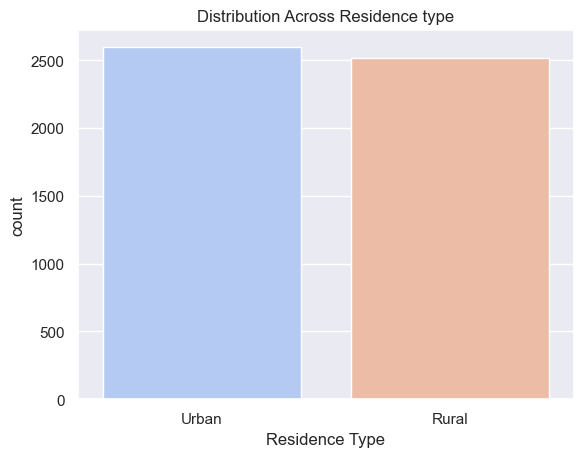

In [436]:
sns.countplot(data=stroke_prediction, x='Residence_type', palette='coolwarm', hue='Residence_type')

plt.title('Distribution Across Residence type')
plt.xlabel('Residence Type')
plt.show()

Distribution Across Smoking Status with Gender

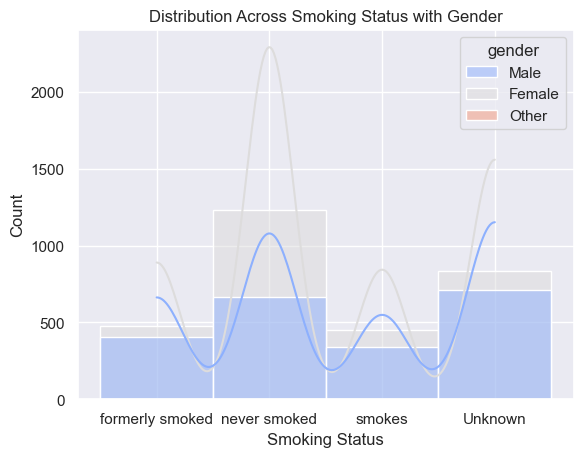

In [437]:
sns.histplot(data=stroke_prediction, x='smoking_status', palette='coolwarm', hue='gender', kde=True)

plt.title('Distribution Across Smoking Status with Gender')
plt.xlabel('Smoking Status')
plt.show()

Distribution Across Work type with Gender

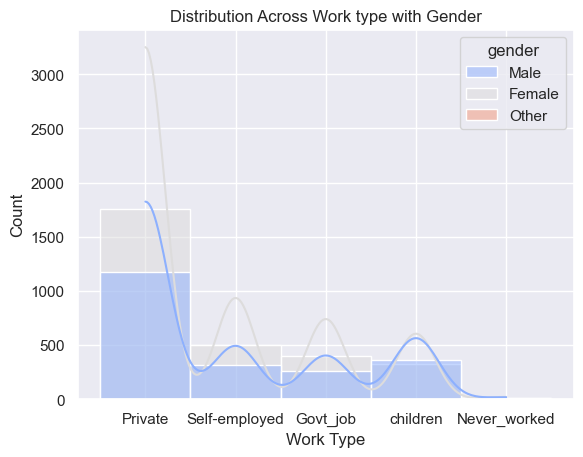

In [438]:
sns.histplot(data=stroke_prediction, x='work_type', palette='coolwarm', hue='gender', kde=True)

plt.title('Distribution Across Work type with Gender')
plt.xlabel('Work Type')
plt.show()

Distribution Across Age and BMI with Gender

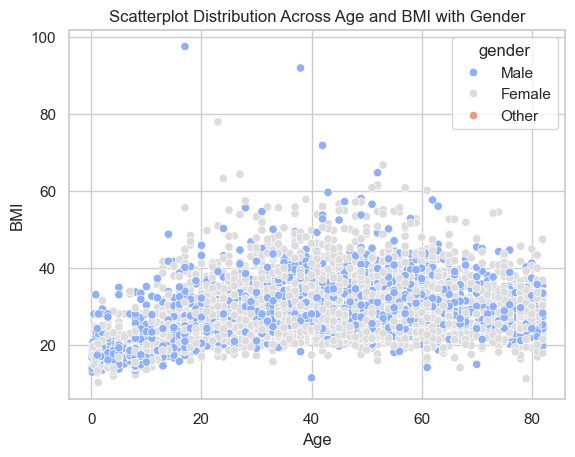

In [439]:
sns.set_style('whitegrid')
sns.scatterplot(data=stroke_prediction, x='age', y='bmi', palette='coolwarm', hue='gender')

plt.title('Scatterplot Distribution Across Age and BMI with Gender')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()


Distribution Across Average Glucose Level and BMI with Gender

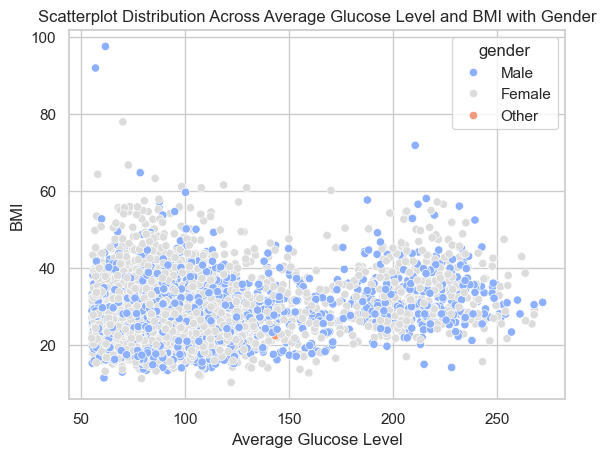

In [440]:
sns.set_style('whitegrid')
sns.scatterplot(data=stroke_prediction, x='avg_glucose_level', y='bmi', palette='coolwarm', hue='gender')

plt.title('Scatterplot Distribution Across Average Glucose Level and BMI with Gender')
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.show()

Encoding Target Column (y)
-

Encoding target variable "stroke" to numeric so the model can handle them using LabelEncoder

In [441]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

stroke_prediction['stroke'] = le.fit_transform(stroke_prediction['stroke'])

Encoding Features Column (X)
-

In [442]:
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# One-hot encode categorical features
encoder = OneHotEncoder(drop='first')
X_cat = encoder.fit_transform(stroke_prediction[categorical_features]).toarray()
X_num = stroke_prediction.drop(categorical_features + ['stroke', 'id'], axis=1)
X = pd.concat([X_num.reset_index(drop=True), pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(categorical_features))], axis=1)

In [443]:
print("X shape:", X.shape)
print("X columns:", list(X.columns))

X shape: (5110, 16)
X columns: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [444]:
stroke_prediction.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Age has the strongest (weak moderate) relationship with stroke, while hypertension, glucose level and heart disease have only slight influence. Most other variable show little to no meaningful relationship, meaning stroke is not strongly predicted by any single factor but rather by a combination of multiple



Feature Selection and Data Splitting
-

We separate the features (X) and target variable (y) and split the dataset into training and testing sets.

X = stroke_prediction.drop(['stroke'], axis=1)

y = stroke_prediction['stroke'] defines y as the target variable, which we want to predict.

train_test_split() splits data into 80% training and 20% testing for model evaluation.

In [445]:
from sklearn.model_selection import train_test_split

y = stroke_prediction['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print('X_train shape: {}'.format(X_train.shape))
print('y_train shape: {}'.format(y_train.shape))
print('X_test shape: {}'.format(X_test.shape))
print('y_test shape: {}'.format(y_test.shape))

X_train shape: (4088, 16)
y_train shape: (4088,)
X_test shape: (1022, 16)
y_test shape: (1022,)


Feature Scaling
-

Since features are on different scales we apply standardization to improve model performance. It prevents models from being biased toward larger numerical values and improves convergence speed in optimization algorithms

StandardScaler(): Standardizes data by transforming it to have a mean of 0 and a standard deviation of 1 ensuring all features are on a similar scale.

fit_transform(X_train): Fits the scaler to the training data and transforms it.

transform(X_test): Transforms the test data using the same scaling parameters.

In [446]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)


Model Selection, Training and Evaluation
-

Using Logistic Regression and RandomForestClassifier


Handling Class Imbalance:

Stroke datasets are almost always heavily imbalanced, very few patient actually have strokes. If ignored the model just predict "No" for everyone and still get 95% accuracy

Logistic Regression

In [447]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', )
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print(y_pred)

print('Intercept: {}'.format(lr.intercept_))
print('Coefficient: \n{}'.format(lr.coef_))

[0 0 1 ... 1 0 0]
Intercept: [-1.22043718]
Coefficient: 
[[ 1.85928928  0.14847648  0.09113626  0.16874509  0.03935887 -0.04178406
   0.          0.04328411 -0.17255856  0.01113448 -0.04995971  0.40075905
   0.00346253  0.05599131 -0.04958211  0.10823784]]


In [448]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.74


RandomForestClassifier

In [449]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [450]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.95


Classification Report

In [451]:
cl = classification_report(y_test, y_pred)
print(cl)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



Confunsion Matrix and Performance Matrix
-

we evaluate precision, recall and accuracy using confusion matrix

In [452]:
print(confusion_matrix(y_test, y_pred))

[[971   1]
 [ 50   0]]


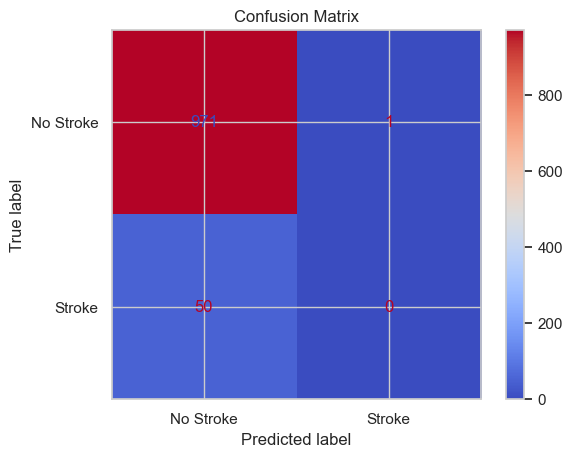

In [453]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='coolwarm')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows the model's performance. True Negatives (No Stroke predicted correctly), False Positives, False Negatives, True Positives (Stroke predicted correctly). With class imbalance, focus on recall for the minority class.

Correlation with Target variable
-

HeatMap Correlation of other Variable Features with target variable "stroke"

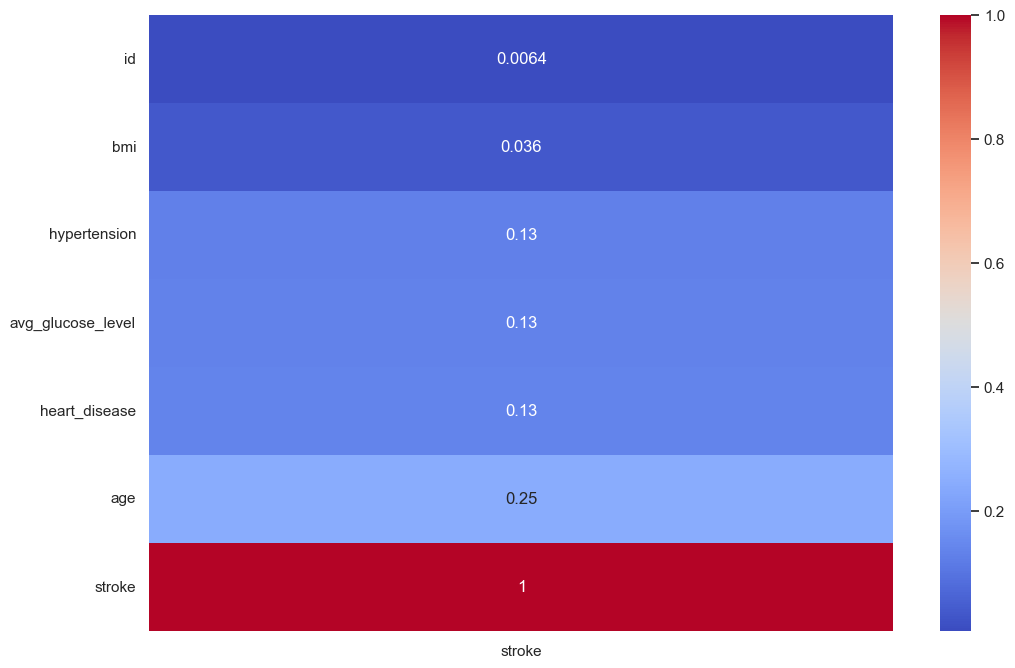

In [454]:
corr = stroke_prediction.select_dtypes(include='number').corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr[['stroke']].sort_values('stroke'), annot=True, cmap='coolwarm')
plt.show()